# Derivatives and Gradients in Deep Learning

Derivatives and gradients are fundamental concepts in neural networks.

They help the neural network understand:

- How the loss changes
- How each weight affects the loss
- Which direction the weights should move
- How much the weights should be updated

The overall training process is:

**Forward Propagation → Loss → Backpropagation → Gradients → Weight Update**

## What is a Derivative?

A derivative tells us how quickly one value changes when another value changes.

For example:

$$
y = x^2
$$

The derivative is:

$$
\frac{dy}{dx} = 2x
$$

If:

$$
x = 3
$$

then:

$$
\frac{dy}{dx} = 2(3) = 6
$$

This means that around $x=3$, a small change in $x$ produces approximately a 6-times larger change in $y$.

### Simple intuition

The derivative represents the **slope** of a function.

- Positive derivative → function is increasing
- Negative derivative → function is decreasing
- Zero derivative → function is flat

In [1]:
def derivative(x):
    return 2 * x

x = 3

print("x:", x)
print("Derivative:", derivative(x))

x: 3
Derivative: 6


## Visualizing a Derivative

Consider:

$$
y = x^2
$$

Its derivative is:

$$
\frac{dy}{dx} = 2x
$$

The derivative tells us the slope at every point on the curve.

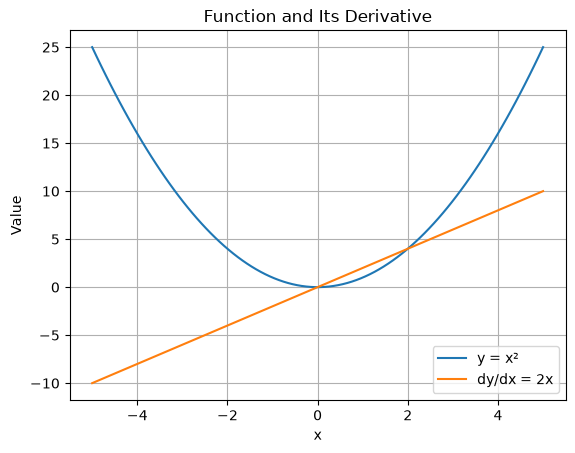

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

y = x**2
dy = 2*x

plt.plot(x, y, label="y = x²")
plt.plot(x, dy, label="dy/dx = 2x")

plt.xlabel("x")
plt.ylabel("Value")
plt.title("Function and Its Derivative")
plt.legend()
plt.grid()

plt.show()

## Why Do Neural Networks Need Derivatives?

A neural network contains many learnable parameters:

- Weights
- Biases
- CNN kernel weights

During training, the model produces a prediction.

We then calculate the loss.

The important question is:

> How should we change the weights to reduce the loss?

We calculate derivatives such as:

$$
\frac{\partial L}{\partial W}
$$

This tells us how the loss $L$ changes when a weight $W$ changes.

Therefore:

**Derivative = information about how a parameter affects the loss.**

## A Simple Neuron

A neuron can be represented as:

$$
z = wx + b
$$

Where:

- $x$ = input
- $w$ = weight
- $b$ = bias
- $z$ = neuron output before activation

Suppose:

$$
x=2
$$

$$
w=3
$$

$$
b=1
$$

Then:

$$
z = (3)(2)+1
$$

$$
z=7
$$

In [3]:
x = 2
w = 3
b = 1

z = w * x + b

print("Neuron output:", z)

Neuron output: 7


## Loss Function

Suppose the true target is:

$$
y=10
$$

Our model predicted:

$$
\hat{y}=7
$$

We can use squared error:

$$
L=(y-\hat{y})^2
$$

Therefore:

$$
L=(10-7)^2
$$

$$
L=9
$$

The model has a loss of 9.

In [4]:
y_true = 10
y_pred = 7

loss = (y_true - y_pred) ** 2

print("Loss:", loss)

Loss: 9


## What is a Gradient?

A gradient is a collection of derivatives.

Suppose a model has three weights:

$$
W = [w_1,w_2,w_3]
$$

We calculate:

$$
\frac{\partial L}{\partial w_1}
$$

$$
\frac{\partial L}{\partial w_2}
$$

$$
\frac{\partial L}{\partial w_3}
$$

Together they form the gradient:

$$
\nabla_W L =
\left[
\frac{\partial L}{\partial w_1},
\frac{\partial L}{\partial w_2},
\frac{\partial L}{\partial w_3}
\right]
$$

So:

**Derivative → one direction**

**Gradient → derivatives for multiple parameters**

In [5]:
gradient = [0.8, -0.3, 0.1]

print("Gradient:", gradient)

Gradient: [0.8, -0.3, 0.1]


## Gradient Descent

The gradient tells us the direction in which the loss increases.

We want to move in the opposite direction.

The weight update equation is:

$$
W_{new} = W_{old} - \eta \nabla_W L
$$

Where:

- $W_{old}$ = current weight
- $\eta$ = learning rate
- $\nabla_W L$ = gradient
- $W_{new}$ = updated weight

The learning rate controls how large the update is.

In [6]:
weight = 5.0
gradient = 2.0
learning_rate = 0.1

new_weight = weight - learning_rate * gradient

print("Old weight:", weight)
print("Gradient:", gradient)
print("Learning rate:", learning_rate)
print("New weight:", new_weight)

Old weight: 5.0
Gradient: 2.0
Learning rate: 0.1
New weight: 4.8


## Chain Rule

Neural networks contain many connected operations.

For example:

$$
w \rightarrow z \rightarrow \hat{y} \rightarrow L
$$

The loss depends on the prediction.

The prediction depends on $z$.

And $z$ depends on the weight.

Therefore, we can calculate:

$$
\frac{dL}{dw}
=
\frac{dL}{d\hat{y}}
\frac{d\hat{y}}{dz}
\frac{dz}{dw}
$$

This is the **chain rule**.

The chain rule is extremely important because it allows us to calculate how the final loss is affected by earlier weights.

## Backpropagation

Backpropagation uses the chain rule to calculate gradients throughout a neural network.

The process is:

**Forward Propagation**

$$
Input \rightarrow Hidden\ Layers \rightarrow Prediction
$$

Then:

$$
Prediction \rightarrow Loss
$$

Then the network works backward:

$$
Loss \rightarrow Gradients \rightarrow Weights
$$

Backpropagation answers:

> How much did each parameter contribute to the final loss?

The calculated gradients are then given to the optimizer.

## Updating Weights

Once gradients are calculated, the optimizer updates the weights.

The basic gradient descent equation is:

$$
W_{new}=W_{old}-\eta\frac{\partial L}{\partial W}
$$

For multiple weights:

$$
W_{new}=W_{old}-\eta\nabla_WL
$$

This process happens repeatedly during training.

Over many iterations, the goal is to reduce the loss.

In [7]:
import numpy as np

weights = np.array([0.5, 0.8, 0.2])

gradients = np.array([0.1, -0.2, 0.05])

learning_rate = 0.1

new_weights = weights - learning_rate * gradients

print("Old weights:")
print(weights)

print("\nGradients:")
print(gradients)

print("\nNew weights:")
print(new_weights)

Old weights:
[0.5 0.8 0.2]

Gradients:
[ 0.1  -0.2   0.05]

New weights:
[0.49  0.82  0.195]
